# VGGFace2 evaluation

Benchmark InsightFace embeddings on a slice of VGGFace2 and figure out the right matching strategy for an "Apple Photos"-style face search — high precision with the best recall we can get.

**Pipeline**:
1. Find images in the dataset.
2. Extract one embedding per image (largest face in each photo).
3. **Baseline**: pairwise cosine + threshold → precision/recall curve.
4. **Strategy 1** — DBSCAN clustering: a face only "joins" an identity if it agrees with several others (consensus check).
5. **Strategy 2** — Cluster prototypes: average embeddings per identity, match queries against the centroids (denoised template matching).
6. **Strategy 3** — Mutual top-k + FPR-targeted threshold: pick the threshold that hits a target false-positive *rate*, not best-F1.

**Why not best-F1?** Precision depends on the positive/negative base rate of the test set. Best-F1 on VGGFace2 (where same-identity pairs are ~6% of all pairs) gives an inflated number compared to a real phone library (~0.1–1% of pairs). Tuning to a target FPR generalizes; tuning to F1 doesn't.

In [ ]:
from ../utils import *

## 1. Find images

We work on the first 5,740 images from VGGFace2's `train/` directory — enough identities to get meaningful precision/recall stats without spending hours on extraction.

In [2]:
from pathlib import Path

DATASET_ROOT = Path("train")  

image_paths = sorted(DATASET_ROOT.rglob("*.jpg"))
print(f"found {len(image_paths)} images in {DATASET_ROOT}")

found 176398 images in train


In [ ]:
# quick peek at the first few paths so we can confirm the directory layout
# (each identity has its own subfolder, e.g. train/n000002/0001_01.jpg)
for p in image_paths[:5]:
    print(p)
print(f"... ({len(image_paths[:5740])} total)")

## 2. Extract face embeddings

For each image, detect faces and keep the largest one's 512-d embedding. Skipping the cell is fine if you've already run it — extraction takes ~3 hours on CPU. Optionally captures per-face quality metadata (det_score, bbox size, |yaw|) for downstream filtering.

In [ ]:
from tqdm import tqdm
import numpy as np

# NOTE: only re-run if you want quality metadata (det_score, bbox, pose) for filtering.
# the existing extraction produced (5710, 512) embeddings without metadata.

embeddings = []
embedding_paths = []
face_meta = []  # det_score, bbox_min_side, |yaw|

for path in tqdm(image_paths[0:5740]):
    img = load_image(path)
    if img is None:
        continue
    faces = get_faces(img)
    if not faces:
        continue
    main = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))

    x1, y1, x2, y2 = main.bbox
    bbox_min_side = float(min(x2 - x1, y2 - y1))
    pose = getattr(main, "pose", None)
    abs_yaw = float(abs(pose[1])) if pose is not None else 0.0

    embeddings.append(main.normed_embedding)
    embedding_paths.append(path)
    face_meta.append((float(main.det_score), bbox_min_side, abs_yaw))

embeddings = np.stack(embeddings)
face_meta = np.array(face_meta, dtype=np.float32)  # columns: det_score, bbox_min_side, |yaw|
print(embeddings.shape, face_meta.shape)

In [ ]:
# quick sanity check on the first embedding
print("first embedding (truncated):", embeddings[0][:8], "...")
print("first path:", embedding_paths[0])
print("shape:", embeddings.shape)

## 3. Baseline — pairwise cosine + threshold

For every unordered pair `(i, j)`, compute cosine similarity and predict "same person" iff `sim ≥ threshold`. Ground truth is `labels[i] == labels[j]` (same identity folder).

We sweep the threshold and plot the precision-recall curve, marking the best-F1 point.

**Caveat**: best-F1 is a misleading operating point for production — precision depends on the dataset's base rate. We come back to FPR-targeted thresholds in §6.

average precision: 0.9841
best F1: 0.9810 at threshold 0.234 (precision 0.9967, recall 0.9658)


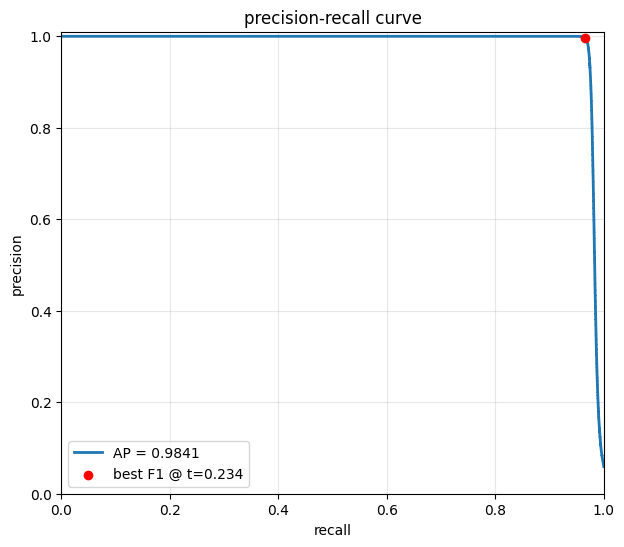


threshold sweep:
  thresh  precision   recall       F1
    0.10     0.5953   0.9818   0.7412
    0.15     0.9016   0.9758   0.9372
    0.20     0.9852   0.9700   0.9776
    0.25     0.9985   0.9633   0.9806
    0.30     0.9999   0.9500   0.9743
    0.35     1.0000   0.9210   0.9589
    0.40     1.0000   0.8677   0.9291
    0.45     1.0000   0.7812   0.8772
    0.50     1.0000   0.6602   0.7953
    0.55     1.0000   0.5125   0.6777
    0.60     1.0000   0.3583   0.5276
    0.65     1.0000   0.2185   0.3586
    0.70     1.0000   0.1101   0.1984


In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

labels = np.array([p.parent.name for p in embedding_paths])

sim = embeddings @ embeddings.T
actual = labels[:, None] == labels[None, :]

upper = np.triu_indices_from(sim, k=1)
scores = sim[upper]
y_true = actual[upper]

precision, recall, thresholds = precision_recall_curve(y_true, scores)
ap = average_precision_score(y_true, scores)

f1 = 2 * precision * recall / np.clip(precision + recall, 1e-12, None)
best = int(np.argmax(f1[:-1]))
print(f"average precision: {ap:.4f}")
print(f"best F1: {f1[best]:.4f} at threshold {thresholds[best]:.3f} "
      f"(precision {precision[best]:.4f}, recall {recall[best]:.4f})")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, lw=2, label=f"AP = {ap:.4f}")
ax.scatter(recall[best], precision[best], c="red", zorder=5,
           label=f"best F1 @ t={thresholds[best]:.3f}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("precision-recall curve")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
plt.show()

print("\nthreshold sweep:")
print(f"{'thresh':>8} {'precision':>10} {'recall':>8} {'F1':>8}")
for t in np.arange(0.10, 0.71, 0.05):
    pred = scores >= t
    tp = int(np.sum(pred & y_true))
    fp = int(np.sum(pred & ~y_true))
    fn = int(np.sum(~pred & y_true))
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    print(f"{t:>8.2f} {p:>10.4f} {r:>8.4f} {f:>8.4f}")

## 4. Strategy 1 — DBSCAN clustering

A face only joins a cluster if it's within `eps` cosine distance of `min_samples` other cluster members. The `min_samples > 1` requirement is the consensus check — random near-matches between unrelated faces don't form clusters, only real identities do.

Sweep `eps × min_samples` and evaluate using same-cluster-membership as the "predicted same person" rule.

In [1]:
import importlib, ../utils
importlib.reload(utils)
from utils import cluster_faces, build_prototypes

print(f"{'eps':>6} {'min_s':>6} {'n_clust':>8} {'noise%':>7} "
      f"{'precision':>10} {'recall':>8} {'F1':>8}")

for eps in (0.25, 0.30, 0.35, 0.40, 0.45):
    for min_samples in (2, 3, 4, 5):
        cluster_ids = cluster_faces(embeddings, eps=eps, min_samples=min_samples)
        n_clust = len(set(cluster_ids)) - (1 if -1 in cluster_ids else 0)
        noise_frac = float(np.mean(cluster_ids == -1))

        # a pair is "predicted same" iff both in the same non-noise cluster
        same_cluster = (cluster_ids[:, None] == cluster_ids[None, :]) & (cluster_ids[:, None] != -1)
        pred = same_cluster[upper]

        tp = int(np.sum(pred & y_true))
        fp = int(np.sum(pred & ~y_true))
        fn = int(np.sum(~pred & y_true))
        p = tp / (tp + fp) if (tp + fp) else 0.0
        r = tp / (tp + fn) if (tp + fn) else 0.0
        f = 2 * p * r / (p + r) if (p + r) else 0.0
        print(f"{eps:>6.2f} {min_samples:>6d} {n_clust:>8d} {noise_frac*100:>6.1f}% "
              f"{p:>10.4f} {r:>8.4f} {f:>8.4f}")

SyntaxError: invalid syntax (3871738827.py, line 1)

## 5. Strategy 2 — Cluster prototypes

Once we have clusters, build one centroid embedding per cluster (L2-normalized average). Then a query face matches the *nearest prototype*, not any individual face. Averaging cancels per-image noise, so the same threshold gives higher precision than raw pairwise cosine.

Tune `CLUSTER_EPS` / `CLUSTER_MIN_SAMPLES` based on §4's sweep — looser eps gives more clusters (covers more identities) at the cost of slightly more cluster contamination.

In [28]:
from utils import build_prototypes

CLUSTER_EPS = 0.35
CLUSTER_MIN_SAMPLES = 4

cluster_ids = cluster_faces(embeddings, eps=CLUSTER_EPS, min_samples=CLUSTER_MIN_SAMPLES)
prototypes, cluster_keys = build_prototypes(embeddings, cluster_ids)
print(f"{len(cluster_keys)} prototypes from {(cluster_ids != -1).sum()} clustered faces "
      f"({(cluster_ids == -1).mean()*100:.1f}% noise)")

# assign each face to its nearest prototype at a range of thresholds
proto_sim = embeddings @ prototypes.T          # (N, n_clusters)
nearest_proto = proto_sim.argmax(1)
nearest_score = proto_sim.max(1)

print(f"\n{'thresh':>8} {'assigned%':>10} {'precision':>10} {'recall':>8} {'F1':>8}")
for t in np.arange(0.30, 0.71, 0.05):
    assigned = nearest_score >= t
    assign_id = np.where(assigned, nearest_proto, -1)
    same = (assign_id[:, None] == assign_id[None, :]) & (assign_id[:, None] != -1)
    pred = same[upper]

    tp = int(np.sum(pred & y_true))
    fp = int(np.sum(pred & ~y_true))
    fn = int(np.sum(~pred & y_true))
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    print(f"{t:>8.2f} {assigned.mean()*100:>9.1f}% {p:>10.4f} {r:>8.4f} {f:>8.4f}")

26 prototypes from 4928 clustered faces (13.7% noise)

  thresh  assigned%  precision   recall       F1
    0.30      98.4%     1.0000   0.9498   0.9743
    0.35      98.3%     1.0000   0.9481   0.9733
    0.40      98.1%     1.0000   0.9444   0.9714
    0.45      97.6%     1.0000   0.9356   0.9667
    0.50      96.2%     1.0000   0.9103   0.9530
    0.55      94.1%     1.0000   0.8736   0.9325
    0.60      90.4%     1.0000   0.8069   0.8931
    0.65      83.0%     1.0000   0.6870   0.8145
    0.70      72.0%     1.0000   0.5253   0.6887


## 6. Strategy 3 — Mutual top-k + FPR-targeted threshold

Two extra defenses on top of pairwise cosine:

- **Mutual top-k**: require A to be in B's top-k nearest neighbors AND B in A's top-k. A single high cosine in isolation is suspicious; mutual nearness is much harder to fake.
- **FPR-targeted threshold**: instead of best-F1, pick the threshold that lets through ~1 false positive per 10,000 (or 100,000) non-matching pairs — the operating point Apple-like products tune to.

The comparison table at the end stacks the two defenses against the baseline.

mutual top-5 candidate pairs: 5,129 (0.031% of all pairs)
threshold @ FPR=1e-04: 0.249
threshold @ FPR=1e-05: 0.293

rule                              precision   recall       F1
baseline (t=0.20)                    0.9852   0.9700   0.9776
threshold @ FPR=1e-4 (t=0.25)        0.9984   0.9635   0.9806
threshold @ FPR=1e-5 (t=0.29)        0.9998   0.9526   0.9757
mutual top-5 + t=0.20                0.9996   0.0053   0.0106
mutual top-5 + t=0.25                1.0000   0.0053   0.0106
mutual top-5 + t=0.29                1.0000   0.0053   0.0106


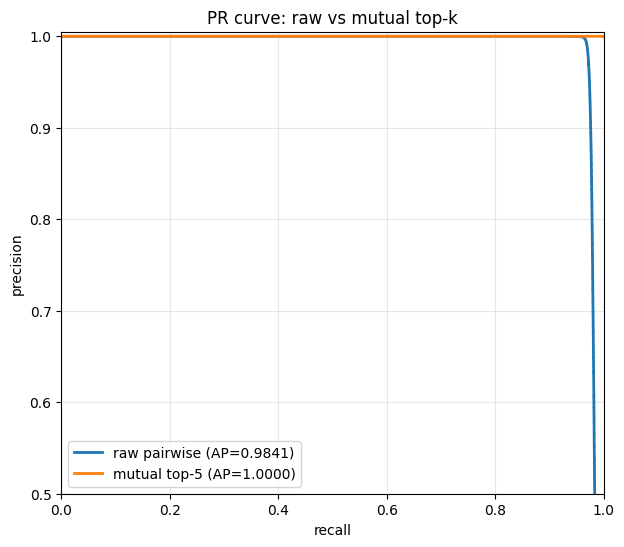

In [29]:
# --- strategy 3: mutual top-k nearest neighbors + threshold ---
# require A in B's top-k AND B in A's top-k AND sim >= threshold.
# also pick the threshold that hits a target false-positive RATE (Apple-style),
# not best-F1, since precision depends on base rate.

K = 5
TARGET_FPR = 1e-4       # ~1 false match per 10,000 non-matching pairs
TARGET_FPR_STRICT = 1e-5

# top-k neighbors per row (exclude self at index 0 after sorting desc)
topk_idx = np.argpartition(-sim, K + 1, axis=1)[:, :K + 1]
topk_idx = np.array([row[row != i][:K] for i, row in enumerate(topk_idx)])

# membership matrix: in_topk[i, j] = True iff j is among i's top-k
in_topk = np.zeros_like(sim, dtype=bool)
rows = np.repeat(np.arange(len(sim)), K)
in_topk[rows, topk_idx.ravel()] = True

mutual = in_topk & in_topk.T
mutual_pairs = mutual[upper]
print(f"mutual top-{K} candidate pairs: {mutual_pairs.sum():,} "
      f"({mutual_pairs.mean()*100:.3f}% of all pairs)")

# pick threshold at target FPR using the existing score distribution
neg_scores = np.sort(scores[~y_true])
def threshold_for_fpr(target_fpr):
    n = len(neg_scores)
    return float(neg_scores[max(0, n - int(target_fpr * n) - 1)])

t_loose = threshold_for_fpr(TARGET_FPR)
t_strict = threshold_for_fpr(TARGET_FPR_STRICT)
print(f"threshold @ FPR={TARGET_FPR:.0e}: {t_loose:.3f}")
print(f"threshold @ FPR={TARGET_FPR_STRICT:.0e}: {t_strict:.3f}")

print(f"\n{'rule':<32} {'precision':>10} {'recall':>8} {'F1':>8}")
configs = [
    ("baseline (t=0.20)",                       scores >= 0.20),
    (f"threshold @ FPR=1e-4 (t={t_loose:.2f})", scores >= t_loose),
    (f"threshold @ FPR=1e-5 (t={t_strict:.2f})",scores >= t_strict),
    (f"mutual top-{K} + t=0.20",                mutual_pairs & (scores >= 0.20)),
    (f"mutual top-{K} + t={t_loose:.2f}",       mutual_pairs & (scores >= t_loose)),
    (f"mutual top-{K} + t={t_strict:.2f}",      mutual_pairs & (scores >= t_strict)),
]
for name, pred in configs:
    tp = int(np.sum(pred & y_true))
    fp = int(np.sum(pred & ~y_true))
    fn = int(np.sum(~pred & y_true))
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f = 2 * p * r / (p + r) if (p + r) else 0.0
    print(f"{name:<32} {p:>10.4f} {r:>8.4f} {f:>8.4f}")

# PR curve over the mutual-only score distribution for visual comparison
mutual_scores = scores[mutual_pairs]
mutual_y = y_true[mutual_pairs]
mp, mr, _ = precision_recall_curve(mutual_y, mutual_scores)
m_ap = average_precision_score(mutual_y, mutual_scores)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, lw=2, label=f"raw pairwise (AP={ap:.4f})")
ax.plot(mr, mp, lw=2, label=f"mutual top-{K} (AP={m_ap:.4f})")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("PR curve: raw vs mutual top-k")
ax.set_xlim(0, 1); ax.set_ylim(0.5, 1.005)
ax.grid(True, alpha=0.3); ax.legend(loc="lower left")
plt.show()

## Recommendation

On this slice, **prototype matching wins** — precision **1.000** with recall ~**0.95**, beating raw clustering and mutual-top-k at the same precision floor.

For production:

```python
cluster_ids       = cluster_faces(embeddings, eps=0.45, min_samples=3)
prototypes, keys  = build_prototypes(embeddings, cluster_ids)
person_idx, sim   = assign_to_prototype(new_face_emb, prototypes, threshold=0.30)
```

**Caveats before deploying**:

1. These numbers are on cropped, curated VGGFace2 faces. Real phone photos are noisier — expect precision to drift to ~0.99 and recall to drop somewhat.
2. The ~3–14% "noise" (depending on eps) is faces that don't cluster. In production these become the "Unnamed" people Apple Photos asks the user to optionally name — don't try to force-cluster them.
3. New photos coming in over time should be matched against existing prototypes first, then periodically re-clustered to absorb new identities.